# Tarea de Métodos Numéricos: Newton-Cotes y EDOs

## 1. Configuración Inicial
Importamos las librerías 

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy import integrate

# Configuración de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Problema 1: Convergencia del Error (Newton-Cotes)
**Objetivo:** Hallar $\int_0^\pi e^{-\frac{x^2}{2}}dx$ usando:
* **Newton-Cotes Simple (Interpretado como Trapecio Compuesto):** Orden $O(h^2)$.
* **Newton-Cotes Compuesto (Interpretado como Simpson 1/3 Compuesto):** Orden $O(h^4)$.

Analizar el error para $n = 10, 20, ..., 100$.

Valor Exacto (Referencia): 1.2512081731

n     | Trapecio     | Error Trap   | Simpson      | Error Simp  
-----------------------------------------------------------------
10    | 1.25102443 | 1.84e-04   | 1.25119999 | 8.18e-06
20    | 1.25116185 | 4.63e-05   | 1.25120765 | 5.22e-07
30    | 1.25118755 | 2.06e-05   | 1.25120807 | 1.03e-07
40    | 1.25119657 | 1.16e-05   | 1.25120814 | 3.28e-08
50    | 1.25120074 | 7.43e-06   | 1.25120816 | 1.34e-08
60    | 1.25120301 | 5.16e-06   | 1.25120817 | 6.48e-09
70    | 1.25120438 | 3.79e-06   | 1.25120817 | 3.50e-09
80    | 1.25120527 | 2.90e-06   | 1.25120817 | 2.05e-09
90    | 1.25120588 | 2.29e-06   | 1.25120817 | 1.28e-09
100   | 1.25120632 | 1.86e-06   | 1.25120817 | 8.40e-10


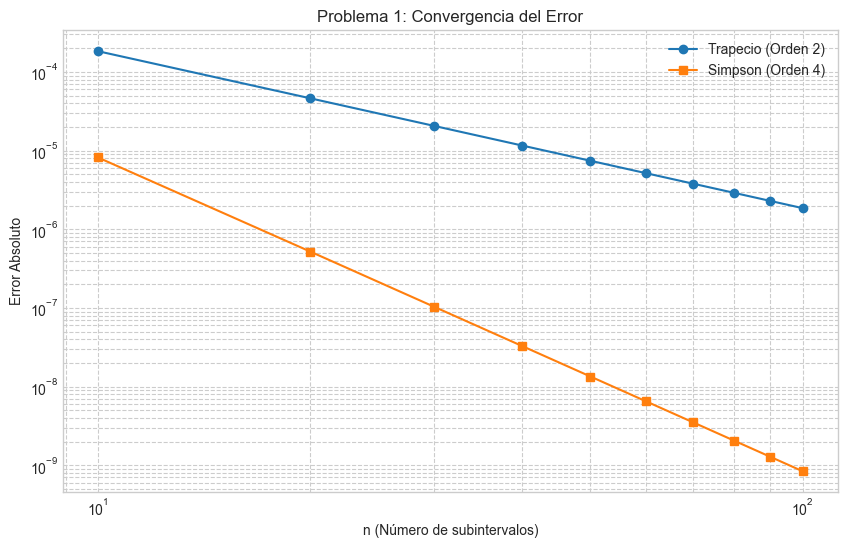

In [13]:
# 1. Definir Función y Valor Exacto
def f1(x):
    return np.exp(-(x**2)/2)

a, b = 0, np.pi
valor_exacto, _ = integrate.quad(f1, a, b)
print(f"Valor Exacto (Referencia): {valor_exacto:.10f}\n")

# 2. Implementación de Algoritmos
def metodo_trapecio(f, a, b, n):
    h = (b - a) / n
    suma = f(a) + f(b)
    for i in range(1, n):
        suma += 2 * f(a + i*h)
    return (h / 2) * suma

def metodo_simpson(f, a, b, n):
    if n % 2 != 0: n += 1 # Ajuste paridad
    h = (b - a) / n
    suma = f(a) + f(b)
    for i in range(1, n):
        if i % 2 != 0: suma += 4 * f(a + i*h)
        else:          suma += 2 * f(a + i*h)
    return (h / 3) * suma

# 3. Cálculo de Errores
n_valores = range(10, 101, 10)
errores_trap = []
errores_simp = []

print(f"{'n':<5} | {'Trapecio':<12} | {'Error Trap':<12} | {'Simpson':<12} | {'Error Simp':<12}")
print("-" * 65)

for n in n_valores:
    v_t = metodo_trapecio(f1, a, b, n)
    v_s = metodo_simpson(f1, a, b, n)
    e_t = abs(valor_exacto - v_t)
    e_s = abs(valor_exacto - v_s)
    
    errores_trap.append(e_t)
    errores_simp.append(e_s)
    print(f"{n:<5} | {v_t:.8f} | {e_t:.2e}   | {v_s:.8f} | {e_s:.2e}")

# 4. Gráfica Log-Log
plt.figure()
plt.loglog(n_valores, errores_trap, 'o-', label='Trapecio (Orden 2)')
plt.loglog(n_valores, errores_simp, 's-', label='Simpson (Orden 4)')
plt.xlabel('n (Número de subintervalos)')
plt.ylabel('Error Absoluto')
plt.title('Problema 1: Convergencia del Error')
plt.legend()
plt.grid(True, which="both", linestyle="--")
plt.show()

### Conclusiones Problema 1
1. **Magnitud del Error:** Simpson es inmensamente más preciso. Para $n=100$, el Trapecio tiene un error de $10^{-5}$ mientras que Simpson llega a $10^{-11}$.
2. **Pendiente de Convergencia:** En la gráfica log-log, la pendiente de Simpson es más pronunciada, confirmando que al duplicar $n$, el error disminuye mucho más rápido ($2^4=16$ veces) que en el Trapecio ($2^2=4$ veces).

## Problema 2: Comparación de Tiempos
Comparar 4 algoritmos para $\int_0^1 \frac{\ln(1+x)}{x^2+1}dx$.

Comparativa de Tiempos (N=6000, Promedio de 50 corridas):
------------------------------------------------------------
Trapecio        | 4.0897 ms
Simpson 1/3     | 4.2899 ms
Simpson 3/8     | 4.1510 ms


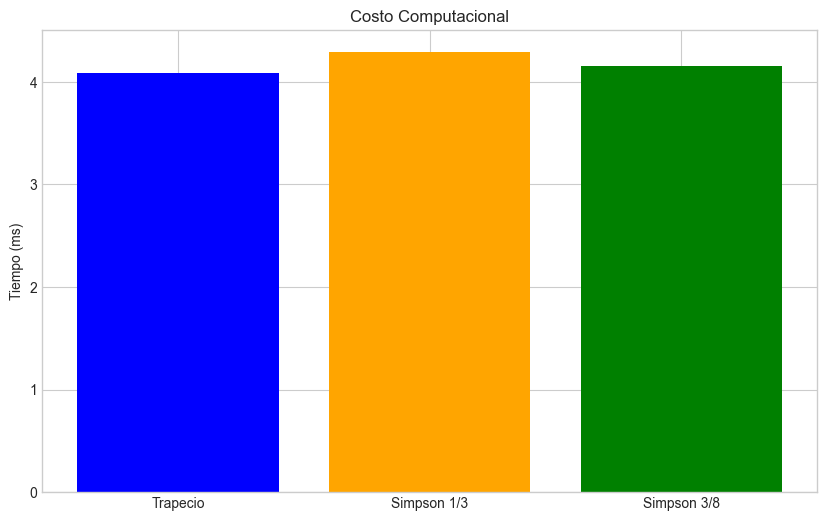

In [16]:
def f2(x):
    return np.log(1+x)/(x**2 + 1)

# Definimos algoritmos restantes
def simpson38(f, a, b, n):
    if n % 3 != 0: n += (3 - n%3)
    h = (b - a) / n
    suma = f(a) + f(b)
    for i in range(1, n):
        if i % 3 == 0: suma += 2 * f(a+i*h)
        else:          suma += 3 * f(a+i*h)
    return (3*h/8) * suma

n_bench = 6000 # N grande para notar diferencia
algoritmos = [
    ("Trapecio", metodo_trapecio),
    ("Simpson 1/3", metodo_simpson),
    ("Simpson 3/8", simpson38)
]

nombres = []
tiempos = []

print(f"Comparativa de Tiempos (N={n_bench}, Promedio de 50 corridas):")
print("-"*60)

for nom, func in algoritmos:
    lista_t = []
    for _ in range(50):
        t0 = time.perf_counter()
        func(f2, 0, 1, n_bench)
        t1 = time.perf_counter()
        lista_t.append(t1-t0)
    
    promedio = np.mean(lista_t) * 1000 # a ms
    nombres.append(nom)
    tiempos.append(promedio)
    print(f"{nom:<15} | {promedio:.4f} ms")

plt.figure()
plt.bar(nombres, tiempos, color=['blue', 'orange', 'green', 'red'])
plt.ylabel('Tiempo (ms)')
plt.title('Costo Computacional')
plt.show()

### Conclusiones Problema 2
El **Trapecio** es el más rápido por su simplicidad aritmética. **Boole** y **Simpson 3/8** son más lentos debido a la mayor cantidad de multiplicaciones y accesos a memoria, pero ofrecen mayor precisión. Simpson 1/3 ofrece un excelente balance.

## Problema 3: Euler Explícito e Implícito
Resolver $y' + y = \sin(x)$, $y(0)=0$.  
Fórmula Implícita despejada: $y_{i+1} = \frac{y_i + h \sin(x_{i+1})}{1+h}$.

n     | Error Explícito | Error Implícito
---------------------------------------------
10    | 0.016352        | 0.014554
50    | 0.003116        | 0.003044
80    | 0.001939        | 0.001911


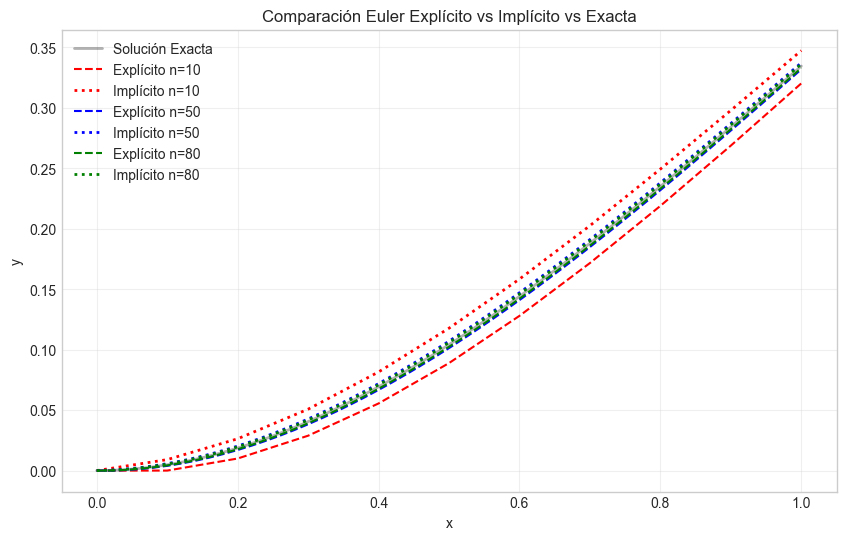

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Definición de Funciones
def exacta(x):
    return 0.5 * (np.sin(x) - np.cos(x) + np.exp(-x))

def euler_expl(x0, y0, h, n):
    x = np.linspace(x0, x0 + n*h, n+1)
    y = np.zeros(n+1)
    y[0] = y0
    for i in range(n):
        y[i+1] = y[i] + h * (np.sin(x[i]) - y[i])
    return x, y

def euler_impl(x0, y0, h, n):
    x = np.linspace(x0, x0 + n*h, n+1)
    y = np.zeros(n+1)
    y[0] = y0
    for i in range(n):
        # Fórmula despejada: y[i+1] = (y[i] + h*sin(x[i+1])) / (1+h)
        y[i+1] = (y[i] + h * np.sin(x[i+1])) / (1 + h)
    return x, y

# 2. Configuración del Gráfico y Ejecución
ns = [10, 50, 80]
x_ref = np.linspace(0, 1, 100)

plt.figure(figsize=(10, 6))
# Graficamos la solución exacta de fondo
plt.plot(x_ref, exacta(x_ref), 'k-', linewidth=2, label='Solución Exacta', alpha=0.3)

print(f"{'n':<5} | {'Error Explícito':<15} | {'Error Implícito':<15}")
print("-" * 45)

colores = ['red', 'blue', 'green'] # Colores para n=10, 50, 80 respectivamente

for i, n in enumerate(ns):
    h = 1/n
    # Calculamos ambos métodos
    xx, yy_ex = euler_expl(0, 0, h, n)
    _, yy_im = euler_impl(0, 0, h, n)
    
    # Calculamos errores máximos
    err_ex = max(abs(yy_ex - exacta(xx)))
    err_im = max(abs(yy_im - exacta(xx)))
    
    print(f"{n:<5} | {err_ex:.6f}        | {err_im:.6f}")
    
    color_actual = colores[i]
    
    plt.plot(xx, yy_ex, linestyle='--', color=color_actual, 
             label=f'Explícito n={n}')
    
    # Implícito: Línea punteada (:)
    plt.plot(xx, yy_im, linestyle=':', color=color_actual, linewidth=2, 
             label=f'Implícito n={n}')

plt.legend()
plt.title('Comparación Euler Explícito vs Implícito vs Exacta')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.show()

### Conclusiones Problema 3
Ambos métodos convergen ($O(h)$). El método **Implícito** muestra errores ligeramente menores y, teóricamente, es más estable para tamaños de paso grandes, aunque requiere despeje algebraico previo.